<a href="https://colab.research.google.com/github/harjasjolly-create/trading-suggestion-project/blob/main/hypothesis_verifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import pandas as pd
data = yf.download("AAPL", period="5d", interval="1m")
import seaborn as sns

/tmp/ipykernel_1252/1471217050.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", period="5d", interval="1m")
[*********************100%***********************]  1 of 1 completed


In [2]:
df=pd.DataFrame(data)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1950 entries, 2026-08-04 13:30:00+00:00 to 2026-08-10 19:59:00+00:00
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1950 non-null   float64
 1   (High, AAPL)    1950 non-null   float64
 2   (Low, AAPL)     1950 non-null   float64
 3   (Open, AAPL)    1950 non-null   float64
 4   (Volume, AAPL)  1950 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 91.4 KB


In [3]:
close,high,low,open,volume=df.iloc[:,0],df.iloc[:,1],df.iloc[:,2],df.iloc[:,3],df.iloc[:,4]


**creating simple moving average(sma)** somewhat an average position vector but of closing prices

In [4]:
sma=close.rolling(window=20).mean()
sma


,Close
,AAPL
Datetime,
2026-08-04 13:30:00+00:00,NaN
2026-08-04 13:31:00+00:00,NaN
2026-08-04 13:32:00+00:00,NaN
2026-08-04 13:33:00+00:00,NaN
2026-08-04 13:34:00+00:00,NaN
...,...
2026-08-10 19:55:00+00:00,307.242935
2026-08-10 19:56:00+00:00,307.281685


[Text(0.5, 0, 'Time'), Text(0, 0.5, 'SMA')]

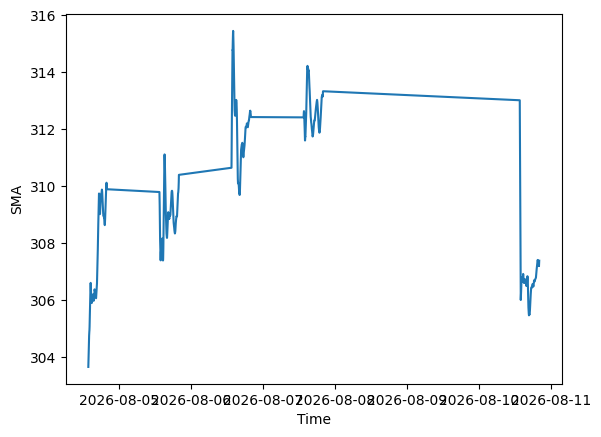

In [5]:
#visualizing sma
sns.lineplot(sma.dropna()).set(xlabel='Time',ylabel='SMA')

**creating average true range(14 candle) (ATR14)**

In [6]:
tr1=high-low
#now we need prev timeframe's close value
close_prev=close.shift(1)
tr2=(high-close_prev).abs()
tr3=(low-close_prev).abs()
values=pd.concat([tr1,tr2,tr3],axis=1)
tr_final=values.max(axis=1)
atr14=tr_final.rolling(window=14).mean()
atr14

,0
Datetime,
2026-08-04 13:30:00+00:00,NaN
2026-08-04 13:31:00+00:00,NaN
2026-08-04 13:32:00+00:00,NaN
2026-08-04 13:33:00+00:00,NaN
2026-08-04 13:34:00+00:00,NaN
...,...
2026-08-10 19:55:00+00:00,0.280156
2026-08-10 19:56:00+00:00,0.280158
2026-08-10 19:57:00+00:00,0.304443


**now building a basic support and resistance model without using detailed candle wick and body analysis**(using only close)

In [7]:
#for now , feeding last 100 closes to kde

In [8]:
last_100_close=close.tail(100)
